## Workflow using Persistence 

Here, we will use a simple workflow for generating a joke and its explanation, but we will maintain history with the help pf persistence in langgraph

In [1]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()

True

Define the model first


In [2]:
model = ChatOpenAI()


Define the state of the graph first

In [4]:
class JokeState(TypedDict):

    #Here first is topic, then generated Joke and its explanation
    topic: str
    joke: str 
    explanation: str 

Now lets define the nodes which are required for making the graph

In [5]:
#Define the node to generate the graph
def generate_joke(State: JokeState):

    #Lets define the prompt first 
    prompt = f" Generate a joke on the topic {State['topic']}"

    #Lets get the joke from the model
    response = model.invoke(prompt).content 

    #Finally return the partial update to the stat e
    return {'joke': response}

#Define the node to generarte the explanation of the joke
def generate_explanation(State: JokeState):

    #Same thing, define the prompt, get the response, update the state
    prompt = f" Generate an explanation for the joke - {State['joke']}"
    response = model.invoke(prompt).content 

    return {'explanation': response}


Now, lets create the graph with the defined nodes above

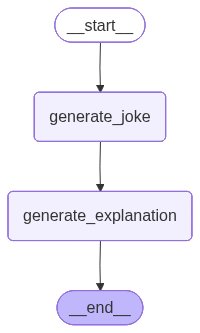

In [8]:
graph = StateGraph(JokeState)

#Lets add the nodes
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

#Now lets add the edges
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

#Now lets define the persistence 
checkpointer= InMemorySaver()

#Lets compile the graph, by passing this checkpointer object to it 
workflow = graph.compile(checkpointer=checkpointer)

workflow

Now lets execute this workflow


In [9]:
#Now this is the format dictionary where the current convo is stored
config1 = {'configurable': {"thread_id": 1}}

#Pass this dictionary while invoking simple
workflow.invoke({'topic': 'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': "Why did the pizza chef go to therapy? Because he couldn't stop tossing and turning at night!",
 'explanation': 'This joke plays on the double meaning of the phrase "tossing and turning." In the context of pizza making, tossing refers to the action of stretching and flipping pizza dough to form the base of the pizza. However, in a more literal sense, tossing and turning is a common phrase used to describe someone who is restless or having difficulty sleeping at night. In this joke, the pizza chef\'s constant tossing and turning at night is humorously attributed to his inability to stop thinking about or practicing his pizza tossing skills, ultimately leading him to seek therapy for his sleep troubles.'}

Now,we can get the state by passing the define config to this get_state() function

In [11]:
workflow.get_state(config=config1)

StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza chef go to therapy? Because he couldn't stop tossing and turning at night!", 'explanation': 'This joke plays on the double meaning of the phrase "tossing and turning." In the context of pizza making, tossing refers to the action of stretching and flipping pizza dough to form the base of the pizza. However, in a more literal sense, tossing and turning is a common phrase used to describe someone who is restless or having difficulty sleeping at night. In this joke, the pizza chef\'s constant tossing and turning at night is humorously attributed to his inability to stop thinking about or practicing his pizza tossing skills, ultimately leading him to seek therapy for his sleep troubles.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1538c3-eacb-663a-8002-26397cc70768'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-19T14:08:43.722896+00:00', paren

Now, lets get the state history at each checkpoint (superstep), with the help of get_state_history() function.

There will be 4 snapshots , since we have 4 nodes:
1. START
2. Generate Joke
3. Explain Joke
4. END

In [13]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza chef go to therapy? Because he couldn't stop tossing and turning at night!", 'explanation': 'This joke plays on the double meaning of the phrase "tossing and turning." In the context of pizza making, tossing refers to the action of stretching and flipping pizza dough to form the base of the pizza. However, in a more literal sense, tossing and turning is a common phrase used to describe someone who is restless or having difficulty sleeping at night. In this joke, the pizza chef\'s constant tossing and turning at night is humorously attributed to his inability to stop thinking about or practicing his pizza tossing skills, ultimately leading him to seek therapy for his sleep troubles.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1538c3-eacb-663a-8002-26397cc70768'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-19T14:08:43.722896+00:00', pare

Now, lets start another thread with another joke topic

In [14]:
config2= {"configurable": {"thread_id": 2}}
workflow.invoke({"topic": "pasta"}, config = config2 )

{'topic': 'pasta',
 'joke': 'Why did the pasta go to the party? Because it heard there would be a spaghetti dance!',
 'explanation': 'This joke plays on the idea of pasta having a fun, party-loving personality. The joke is a play on words, as "spaghetti dance" sounds like "spaghetti and dance," which is a common meal and activity at parties. The joke suggests that the pasta wanted to go to the party to participate in the spaghetti dance, which is a humorous and silly concept. The punchline is meant to be lighthearted and whimsical, making the listener chuckle at the idea of pasta attending a party for a specific type of dance.'}

Now, lets see if we are able to get 2 threads since we have invoked 2 etc

In [15]:
workflow.get_state(config=config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta go to the party? Because it heard there would be a spaghetti dance!', 'explanation': 'This joke plays on the idea of pasta having a fun, party-loving personality. The joke is a play on words, as "spaghetti dance" sounds like "spaghetti and dance," which is a common meal and activity at parties. The joke suggests that the pasta wanted to go to the party to participate in the spaghetti dance, which is a humorous and silly concept. The punchline is meant to be lighthearted and whimsical, making the listener chuckle at the idea of pasta attending a party for a specific type of dance.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1538d7-f6e5-64de-8002-8b1f869e5a80'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-19T14:17:41.862717+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1538d7-dcde-6937-8

In [16]:
workflow.get_state(config = config1)

StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza chef go to therapy? Because he couldn't stop tossing and turning at night!", 'explanation': 'This joke plays on the double meaning of the phrase "tossing and turning." In the context of pizza making, tossing refers to the action of stretching and flipping pizza dough to form the base of the pizza. However, in a more literal sense, tossing and turning is a common phrase used to describe someone who is restless or having difficulty sleeping at night. In this joke, the pizza chef\'s constant tossing and turning at night is humorously attributed to his inability to stop thinking about or practicing his pizza tossing skills, ultimately leading him to seek therapy for his sleep troubles.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1538c3-eacb-663a-8002-26397cc70768'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-19T14:08:43.722896+00:00', paren

Hence we are able to see both the threads since the application is still running and RAM is still active etc.

Now, ofc we can also see the state history of the thread 2.


In [17]:
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta go to the party? Because it heard there would be a spaghetti dance!', 'explanation': 'This joke plays on the idea of pasta having a fun, party-loving personality. The joke is a play on words, as "spaghetti dance" sounds like "spaghetti and dance," which is a common meal and activity at parties. The joke suggests that the pasta wanted to go to the party to participate in the spaghetti dance, which is a humorous and silly concept. The punchline is meant to be lighthearted and whimsical, making the listener chuckle at the idea of pasta attending a party for a specific type of dance.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1538d7-f6e5-64de-8002-8b1f869e5a80'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-19T14:17:41.862717+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1538d7-dcde-6937-

### Time Travel use-case of persistence

Here, we want to resume the workflow from the point where input is already received and workflow of joke generation didnt start yet. 

Lets see how can we do that.

Every check point has an ID, we can simply use that ID to go to that checkpoint.

We will simply copy the checkpoint ID from the above cell. 


Lets get the state at that check point first, to test it.



In [19]:
workflow.get_state({
    "configurable": {
        "thread_id": 2,
        "checkpoint_id": "1f1538d7-d538-61be-8000-abd3423f9ec5"
    }
})

StateSnapshot(values={'topic': 'pasta'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f1538d7-d538-61be-8000-abd3423f9ec5'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-19T14:17:38.331461+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1538d7-d534-68b7-bfff-53907bdf9eb2'}}, tasks=(PregelTask(id='1c3ad8ca-33eb-4447-2992-196f9890f831', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pasta go to the party? Because it heard there would be a spaghetti dance!'}),), interrupts=())

Now, lets see if we can resume the workflow, from the above checkpoint with its id.

So, as usual, we need to give the initial state as None, and simply pass the config, but this time with checkpoint_id.

In [20]:
workflow.invoke(None, config={
    "configurable": {
        "thread_id": 2,
        "checkpoint_id": "1f1538d7-d538-61be-8000-abd3423f9ec5"
    }
})

{'topic': 'pasta',
 'joke': 'Why did the spaghetti bring a map to dinner? Because it wanted to find its way through the pasta maze!',
 'explanation': 'This joke plays on the word "pasta" which can refer to both spaghetti and other types of pasta dishes as well as a maze or confusing situation. In this case, the spaghetti brought a map to dinner because it wanted to navigate its way through the pasta maze, implying that the spaghetti itself is lost or confused in the dish. It\'s a playful and light-hearted way to imagine spaghetti as a character trying to find its way in a complicated situation.'}

Now, this new execution is also saved in the state history.

Now, why did this happen?

Now, when we execute the workflow from any point, in the history ,its like opening an alternate timeline again from that point causing the existing timeline to branch and form a new timeline.

Now, all the timelines are a part of the same history, so those snap shots also get added to the history.

In [21]:
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti bring a map to dinner? Because it wanted to find its way through the pasta maze!', 'explanation': 'This joke plays on the word "pasta" which can refer to both spaghetti and other types of pasta dishes as well as a maze or confusing situation. In this case, the spaghetti brought a map to dinner because it wanted to navigate its way through the pasta maze, implying that the spaghetti itself is lost or confused in the dish. It\'s a playful and light-hearted way to imagine spaghetti as a character trying to find its way in a complicated situation.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f153a41-67f6-69ba-8003-44d7049aee3d'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-19T16:59:24.238664+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f153a41-5bf8-6b17-8002-764937dceb8a'}}, tasks=(), i

### Now, taking advantage of the same time travel, we can even change the values of the state by going to any particular check point also.

Its like git version control but for workflows.

### This is called Updating the state

Now, lets update the value of the input from 'pasta' to 'samosa' , after receiving the input.

In [22]:
workflow.update_state(
    {'configurable':
     {
         'thread_id': 2,
         "checkpoint_id": "1f1538d7-d538-61be-8000-abd3423f9ec5",
         "checkpoint_ns": ""
     }},
     {'topic': 'samosa'}
)

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f153a54-e2fa-6e64-8001-841918db1a0e'}}

Now, lets check the state history again to see if any changes happen etc.

We can see that we have a new state, which is added as new, but did not change the history, because it is version control kindoff which will not overwrite the already written timeline, but it just keeps on creating a new branches etc.

In [23]:
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f153a54-e2fa-6e64-8001-841918db1a0e'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-19T17:08:07.165278+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1538d7-d538-61be-8000-abd3423f9ec5'}}, tasks=(PregelTask(id='3c7112e7-73e3-7028-73df-9076e3e5ced0', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti bring a map to dinner? Because it wanted to find its way through the pasta maze!', 'explanation': 'This joke plays on the word "pasta" which can refer to both spaghetti and other types of pasta dishes as well as a maze or confusing situation. In this case, the spaghetti brought a map to dinner because it wa

Now that we have created a new state, lets invoke the workflow from that state, to create another timeline branch.

Since this is a new state, it will have new checkpoint_id, even we have updated the state with the previous checkpoint_id, that did not get overridden, but a it is copied and replaced the values that we require and new state got created etc.

Lets take that new checkpoint_id and run the workflow from that point, and lets see if we can get a 'samosa' joke.

Yes we got it.

In [25]:
workflow.invoke(None, config={
    "configurable": {
        "thread_id": 2,
        "checkpoint_id": "1f153a54-e2fa-6e64-8001-841918db1a0e"
    }
})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy? \n\nBecause it had too many layers to work through!',
 'explanation': 'This joke plays on the idea that samosas are a type of Indian pastry that typically have multiple layers of dough and filling. By saying that the samosa went to therapy because it had too many layers to work through, the joke suggests that the samosa has emotional issues or inner conflicts that it needs help resolving, similar to a person going to therapy to work through their own issues.'}

Now, lets check the new state history, to see if one more new branch is created or not.
It is created.

In [26]:
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy? \n\nBecause it had too many layers to work through!', 'explanation': 'This joke plays on the idea that samosas are a type of Indian pastry that typically have multiple layers of dough and filling. By saying that the samosa went to therapy because it had too many layers to work through, the joke suggests that the samosa has emotional issues or inner conflicts that it needs help resolving, similar to a person going to therapy to work through their own issues.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f153a63-1f01-673d-8003-048a610cb029'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-19T17:14:29.269064+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f153a63-0c8d-6ba8-8002-d7beb9ba37a9'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did t